In [1]:
import matplotlib.pyplot as plt 
from ipywidgets import interact
import numpy as np

## 0. Source Data
https://clearinghouse.isgs.illinois.edu/data/elevation/illinois-height-modernization-ilhmp

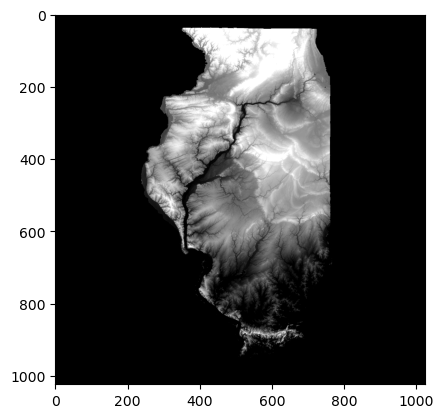

In [2]:
dem = plt.imread('IL_Statewide_Lidar_DEM_WGS.png')[:,:,0]
plt.imshow(dem, cmap='gray', vmin=0, vmax=1)

H, W = dem.shape

## 1. Computer Graphics Primer

### 1.0. Vectors
- Dot product of unit vectors: $\vec{u}\cdot\vec{v} = u_xv_x + u_yv_y + u_zv_z = cos\theta$
- Cross product of unit vectors $\vec{u}\times\vec{v} = (u_yv_z-u_zv_y)\vec{e}_x + (u_zv_x-u_xv_z)\vec{e}_y + (u_xv_y-u_yv_x)\vec{e}_z = sin\theta\ \vec{n}$

### 1.1. Surfaces
Given a surface $S(x, y) = (x, y, f(x, y))^\top$. The tangent vectors are 
$$\vec{u}(x,y) = \frac{\partial S}{\partial x}(x,y) = \left(1, 0, \frac{\partial f}{\partial x}(x, y)\right)^\top, \quad
\vec{v}(x,y) = \frac{\partial S}{\partial y}(x,y) = \left(0, 1, \frac{\partial f}{\partial x}(x, y)\right)^\top$$
The unnormalized normal vector is
$$\vec{n}(x,y) = \vec{u}(x,y)\times\vec{v}(x,y) = \left(-\frac{\partial f}{\partial x}(x, y), -\frac{\partial f}{\partial y}(x, y), 2\right)^\top$$
The discretized (finite difference) version is:
$$\vec{n}[i,j] = \left(\frac{f[i, j-1] - f[i, j+1]}{2}, \frac{f[i+1,j] - f[i-1,j]}{2}, 2\right)^\top$$


### 1.2 Phong Shading
Given surface normal (unit vector) $\vec{n}$, light direction (unit vector) $\vec{l}$, eye direction (unit vector) $\vec{v}$, the reflected light direction (unit vector) is $r = 2 (\vec{l}\cdot \vec{n})\vec{n} - \vec{l}$.

A pixel's color $I$ is made up of three components:
- Ambient lighting: $K_{a}$ (constant)
- Diffuse lighting: $K_{d}\ \vec{l} \cdot \vec{n}$ (depends on lighting direction, not on viewing direction)
- Specular lighting: $K_{s}\ (\vec{r} \cdot \vec{v})^ r$  (depends on both lighting and viewing directions)

$$I = K_{a} + K_{d}\ \vec{l} \cdot \vec{n} + K_{s}\ (\vec{r} \cdot \vec{v})^r$$

## 2. Looping in Python (Very Slow)

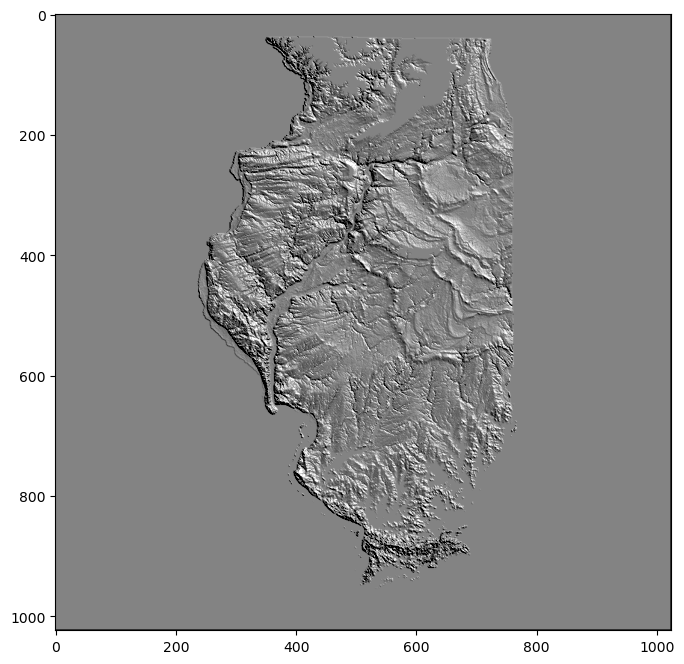

In [3]:
def render(exaggeration=20, theta=50, phi=30, k_ambient=0.2, k_diffuse=0.5, k_specular=0.5):
    out = np.zeros((H, W))

    def render_pixel(i, j):
        v = np.array([0, 0, 1])

        n = np.array([
            exaggeration * (dem[i][j - 1] - dem[i][j + 1]), # -df/dx
            exaggeration * (dem[i + 1][j] - dem[i - 1][j]), # -df/dy
            4
        ])
        n /= np.linalg.norm(n)
        
        l = np.array([
            np.cos(np.radians(phi)) * np.cos(np.radians(theta)),
            np.cos(np.radians(phi)) * np.sin(np.radians(theta)),
            np.sin(np.radians(phi))
        ])
        l /= np.linalg.norm(l)
        
        d = l.dot(n)
        r = n * 2 * d - l

        diffuse = d
        specular = r.dot(v) ** 3
        
        out[i, j] = k_ambient + k_diffuse * diffuse + k_specular * specular
    
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            render_pixel(i, j)
            
    plt.figure('naive', figsize=(8,8))
    plt.imshow(out, cmap='gray', vmin=0, vmax=1)

render()

## 3. Using NumPy (Faster)

In [4]:
@interact(exaggeration=(0,20), theta=(0,360), phi=(0,90), k_ambient=(0,1.), k_diffuse=(0,1.), k_specular=(0,1.))
def render_optimized(exaggeration=10, theta=10, phi=30, k_ambient=0.2, k_diffuse=0.5, k_specular=0.5):
    v = np.tile(np.array([0, 0, 1]).reshape((3, 1, 1)), (1, H - 2, W - 2))
    
    n = np.stack([
        exaggeration * (dem[1:-1, :-2] - dem[1:-1, 2:]), # -df/dx
        exaggeration * (dem[2:, 1:-1] - dem[:-2, 1:-1]), # -df/dy
        np.ones((H - 2, W - 2)) * 4
    ])
    n /= np.linalg.norm(n, axis=0)
    
    l = np.array([
        np.cos(np.radians(phi)) * np.cos(np.radians(theta)),
        np.cos(np.radians(phi)) * np.sin(np.radians(theta)),
        np.sin(np.radians(phi))
    ])
    l /= np.linalg.norm(l)
    l = np.tile(l.reshape((3, 1, 1)), (1, H - 2, W - 2))
    
    d = (l * n).sum(axis=0)
    r = n * 2 * d - l

    diffuse = d
    specular = (r * v).sum(axis=0) ** 3
    
    out = k_ambient + k_diffuse * diffuse + k_specular * specular
    
    plt.figure('numpy', figsize=(8,8))
    plt.imshow(out, cmap='gray', vmin=0, vmax=1)

interactive(children=(IntSlider(value=10, description='exaggeration', max=20), IntSlider(value=10, description…

## 4. Parallelized with WebGPU (Very Fast)

- Demo: https://galmungral.github.io/hillshade/
- Shader source: https://raw.githubusercontent.com/GalMunGral/hillshade/refs/heads/main/hillshade.wgsl
  - Look for `fn fsMain(v: VSOutput) -> @location(0) vec4f`